In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans


from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from joblib import parallel_backend
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [3]:
df.shape

(2200, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(2200, 8)

In [10]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [11]:
 # Method 2: Separate min/max for all features
print("\n=== Min Values per Feature ===")
print(df.min(numeric_only=True))
print("\n=== Max Values per Feature ===")
print(df.max(numeric_only=True))


=== Min Values per Feature ===
N               0.000000
P               5.000000
K               5.000000
temperature     8.825675
humidity       14.258040
ph              3.504752
rainfall       20.211267
dtype: float64

=== Max Values per Feature ===
N              140.000000
P              145.000000
K              205.000000
temperature     43.675493
humidity        99.981876
ph               9.935091
rainfall       298.560117
dtype: float64


In [12]:
# print("Unique crops:", df['Crop_Type'].unique())
# print("\nCrop counts:")
# print(df['Crop_Type'].value_counts())

# print("\nUnique soil types:", df['Soil_Type'].unique())

In [13]:
# features = [ 'Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality']
# scaler = StandardScaler()
# df[features] = scaler.fit_transform(df[features])
# df.head()

In [14]:
# soil_encoder = LabelEncoder()
# df['Soil_Type'] = soil_encoder.fit_transform(df['Soil_Type'])
# df.head()


In [15]:
# crop_encoder = LabelEncoder()
# df['Crop_Type'] = crop_encoder.fit_transform(df['Crop_Type'])
# df.head()

In [16]:
# print("Soil classes:", soil_encoder.classes_)
# print("Crop classes:", crop_encoder.classes_)

In [17]:
# df = df.drop(columns=['Crop_Yield'])
# df.head()

In [18]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

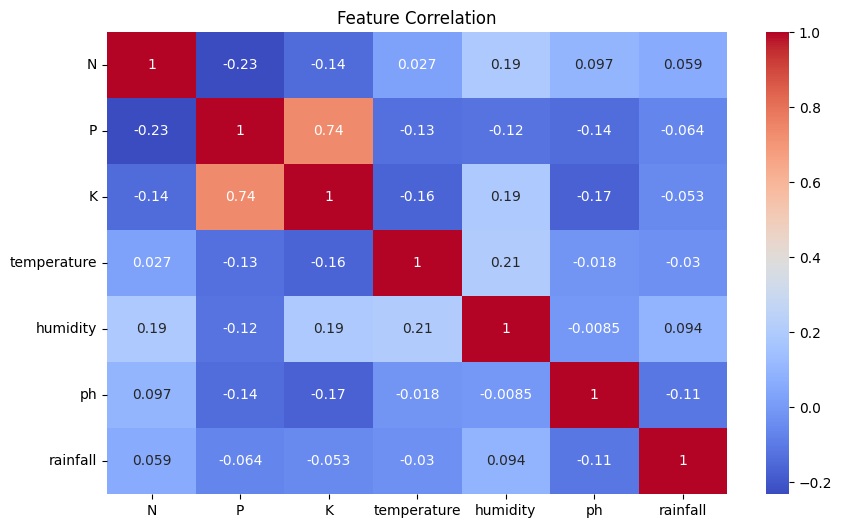

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [20]:
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# from tqdm import tqdm
from colorama import Fore, Style

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

In [21]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [22]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
 

In [23]:
from sklearn.model_selection import train_test_split

x = df[feature_cols]
y = df['label']  
# Train-test split (80-20)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train.shape, x_test.shape


((1760, 7), (440, 7))

In [24]:
x.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

In [25]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
}

### Logistic Regression

In [26]:
LR = LogisticRegression() 
LR.fit(x_train,y_train) 
y_pred = LR.predict(x_test) 
y_proba = LR.predict_proba(x_test)

In [27]:
print(classification_report(y_test, y_pred))

# Metrics with multiclass averaging
acc = accuracy_score(y_test, y_pred)
per = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# For ROC AUC in multiclass
y_proba = LR.predict_proba(x_test)
auc_score = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy: {acc:.4f}, Precision: {per:.4f}, Recall: {rec:.4f}, "
      f"F1: {f1:.4f}, AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.68      0.65      0.67        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      0.95      0.97        20
      coffee       1.00      1.00      1.00        20
      cotton       0.80      1.00      0.89        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.89      0.85      0.87        20
       maize       0.83      0.75      0.79        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.75      0.75      0.75        20
    mungbean       1.00      0.95      0.97        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

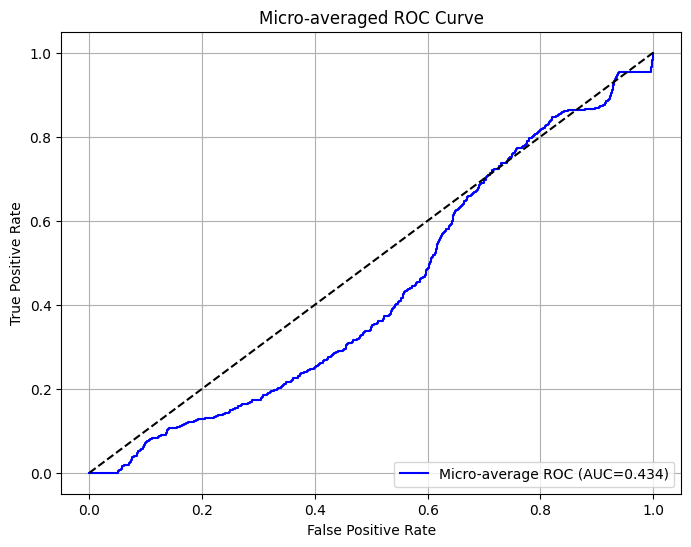

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize
classes = list(set(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# Micro-average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_score = roc_auc_score(y_test_bin, y_proba, average="micro")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC={auc_score:.3f})", color="blue")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


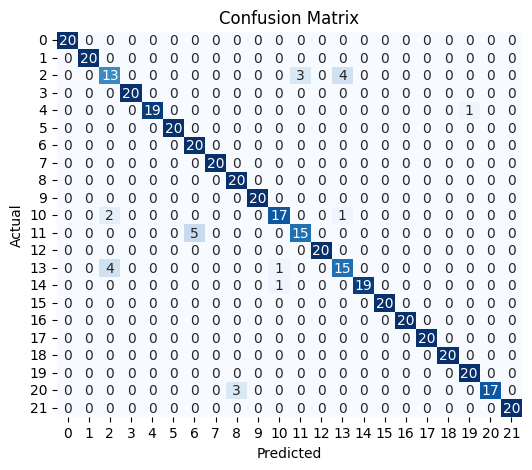

In [29]:
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) 
plt.title('Confusion Matrix') 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show() 

### KNN 

In [30]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)

In [31]:
print(classification_report(y_test, y_pred))

# Metrics with multiclass averaging
acc = accuracy_score(y_test, y_pred)
per = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# For ROC AUC in multiclass
y_proba = knn.predict_proba(x_test)
auc_score = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy: {acc:.4f}, Precision: {per:.4f}, Recall: {rec:.4f}, "
      f"F1: {f1:.4f}, AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.78      0.90      0.84        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

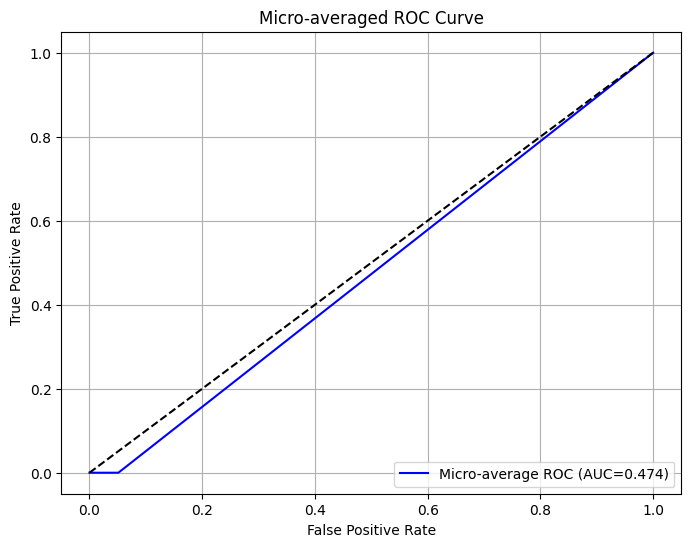

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize
classes = list(set(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# Micro-average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_score = roc_auc_score(y_test_bin, y_proba, average="micro")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC={auc_score:.3f})", color="blue")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


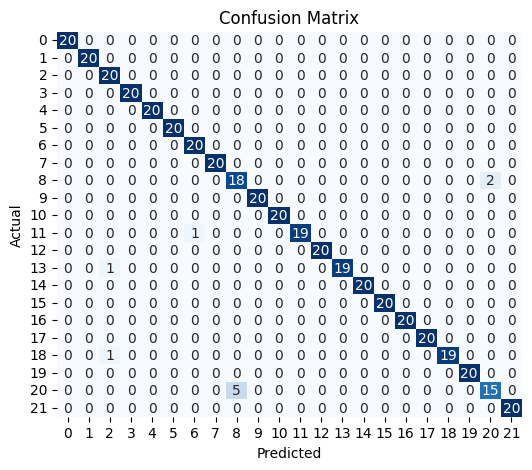

In [33]:
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) 
plt.title('Confusion Matrix') 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show() 

### Decision Tree Classifier

In [34]:
DT = DecisionTreeClassifier()
DT.fit(x_train,y_train)
y_pred = DT.predict(x_test)
y_proba = DT.predict_proba(x_test)

In [35]:
print(classification_report(y_test, y_pred))

# Metrics with multiclass averaging
acc = accuracy_score(y_test, y_pred)
per = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# For ROC AUC in multiclass
y_proba = DT.predict_proba(x_test)
auc_score = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy: {acc:.4f}, Precision: {per:.4f}, Recall: {rec:.4f}, "
      f"F1: {f1:.4f}, AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.90      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.90      0.92        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

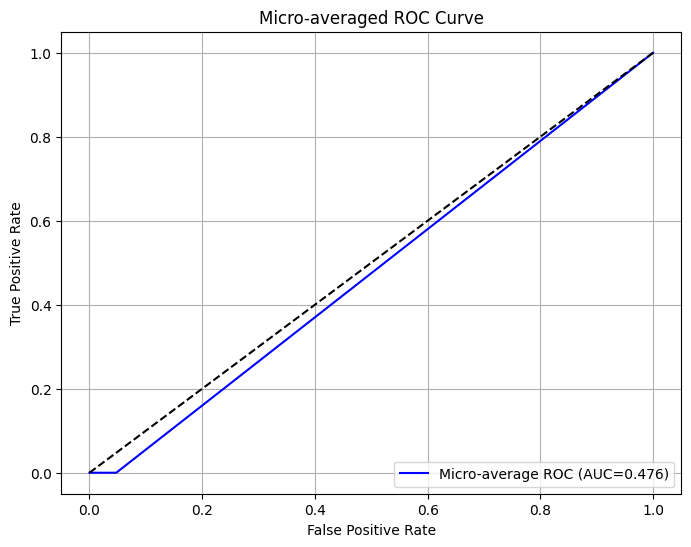

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize
classes = list(set(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# Micro-average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_score = roc_auc_score(y_test_bin, y_proba, average="micro")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC={auc_score:.3f})", color="blue")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


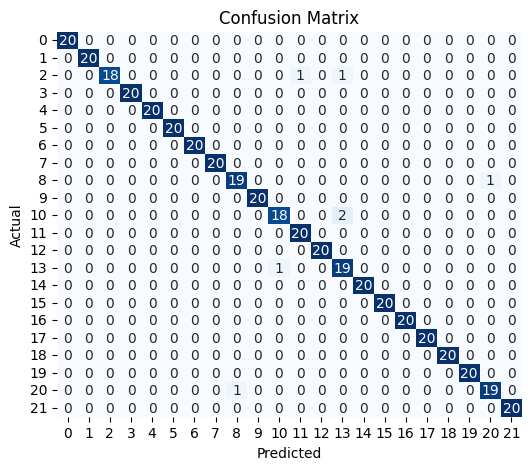

In [37]:
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) 
plt.title('Confusion Matrix') 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show() 

### Random Forest Classifier

In [38]:
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)

y_pred = rfc.predict(x_test)
y_proba = rfc.predict_proba(x_test)

In [39]:
print(classification_report(y_test, y_pred))

# Metrics with multiclass averaging
acc = accuracy_score(y_test, y_pred)
per = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# For ROC AUC in multiclass
y_proba = rfc.predict_proba(x_test)
auc_score = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

best_model=rfc
print(f"Accuracy: {acc:.4f}, Precision: {per:.4f}, Recall: {rec:.4f}, "
      f"F1: {f1:.4f}, AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

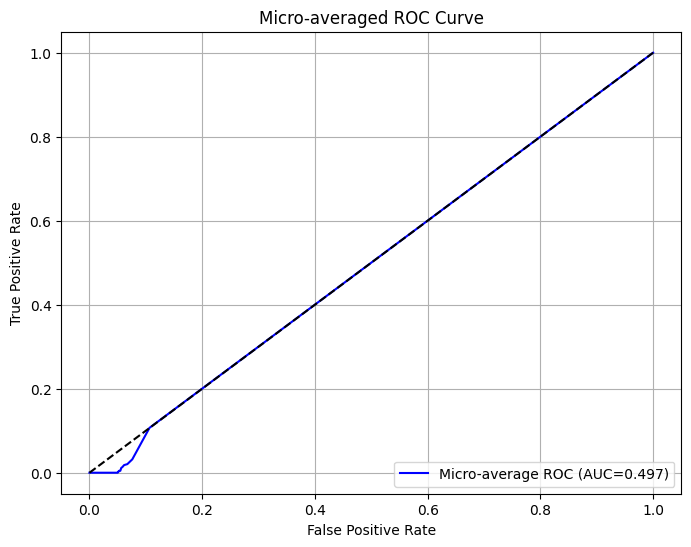

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize
classes = list(set(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# Micro-average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_score = roc_auc_score(y_test_bin, y_proba, average="micro")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC={auc_score:.3f})", color="blue")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


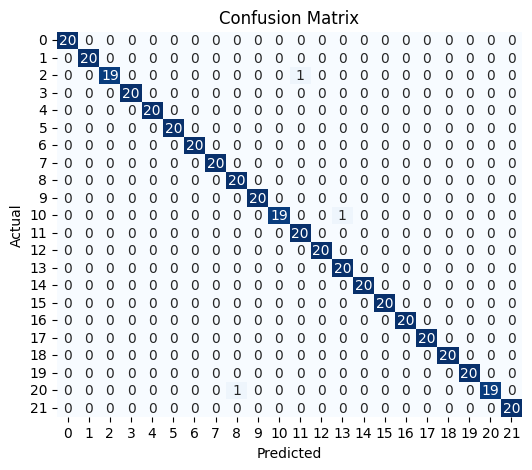

In [41]:
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) 
plt.title('Confusion Matrix') 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show() 

In [42]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


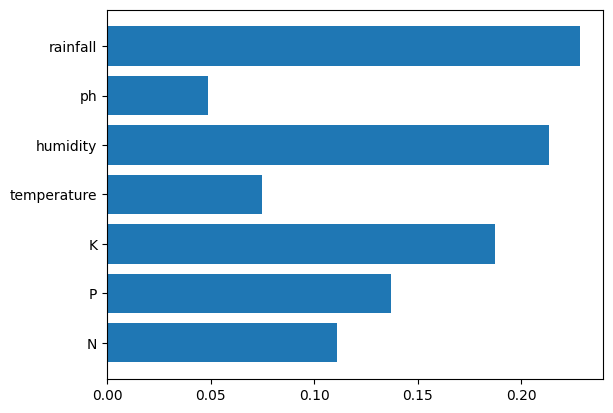

In [43]:
import matplotlib.pyplot as plt

importance = rfc.feature_importances_
plt.barh(feature_cols, importance)
plt.show()

## SVM

In [44]:
svm=SVC()
svm.fit(x_train,y_train)
y_pred = svm.predict(x_test)
y_proba = svm.decision_function(x_test)

In [45]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train SVM with probability=True
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(x_train, y_train)

# Normal predictions
y_pred = svm.predict(x_test)

acc = accuracy_score(y_test, y_pred)
per = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# Probabilities for ROC AUC (multiclass)
y_proba = svm.predict_proba(x_test)

auc_score = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy: {acc:.4f}, Precision: {per:.4f}, Recall: {rec:.4f}, "
      f"F1: {f1:.4f}, AUC: {auc_score:.4f}")


Accuracy: 0.9841, Precision: 0.9866, Recall: 0.9841, F1: 0.9839, AUC: 1.0000


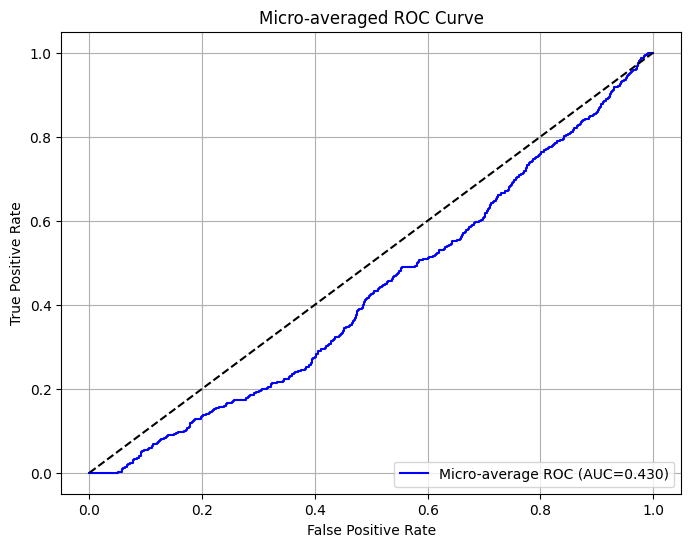

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize
classes = list(set(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# Micro-average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_score = roc_auc_score(y_test_bin, y_proba, average="micro")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC={auc_score:.3f})", color="blue")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


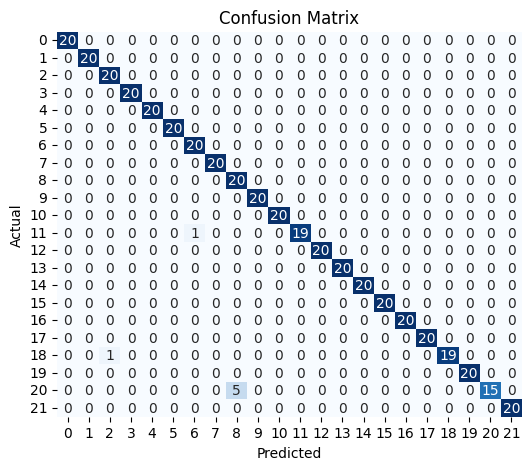

In [47]:
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) 
plt.title('Confusion Matrix') 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show() 

In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score

results = []

models = {
    "RandomForest": rfc,
    "SVM": svm,
    "KNN": knn,
    "LpgisticRegressor" : LR,
    "DecisionTree" : DT
}

for name, model in models.items():
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,RandomForest,0.993182
1,SVM,0.984091
4,DecisionTree,0.984091
2,KNN,0.977273
3,LpgisticRegressor,0.943182


In [49]:
sample = [[90,40,40,25,80,6.5,200]]
print(model.predict(sample))

['rice']


In [50]:
import pickle
pickle.dump(model, open("crop_model.pkl","wb"))

## Hyperparameter Tuning

In [51]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
}


grid_search = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'max_depth': None, 'n_estimators': 100}
Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20

In [52]:
GBC = GradientBoostingClassifier(random_state=10)
GBC.fit(x_train,y_train)
y_pred = GBC.predict(x_test)
y_proba = GBC.predict_proba(x_test)[:, 1]

In [53]:
print(classification_report(y_test, y_pred))

# Metrics with multiclass averaging
acc = accuracy_score(y_test, y_pred)
per = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# For ROC AUC in multiclass
y_proba = GBC.predict_proba(x_test)
auc_score = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy: {acc:.4f}, Precision: {per:.4f}, Recall: {rec:.4f}, "
      f"F1: {f1:.4f}, AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

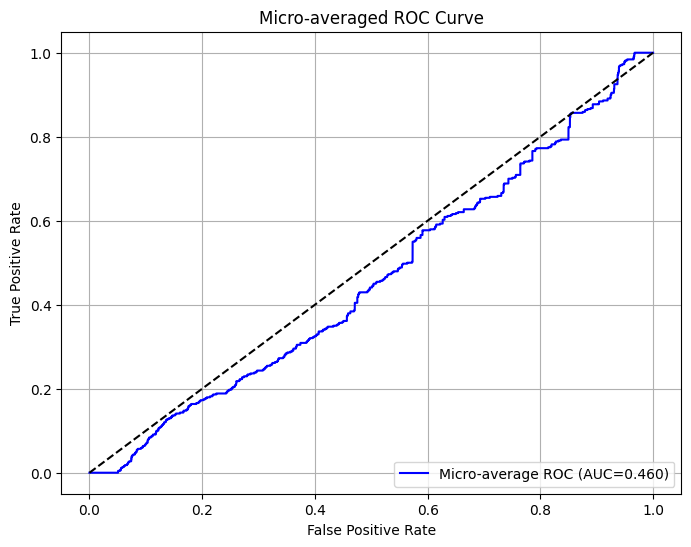

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize
classes = list(set(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# Micro-average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_score = roc_auc_score(y_test_bin, y_proba, average="micro")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC={auc_score:.3f})", color="blue")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


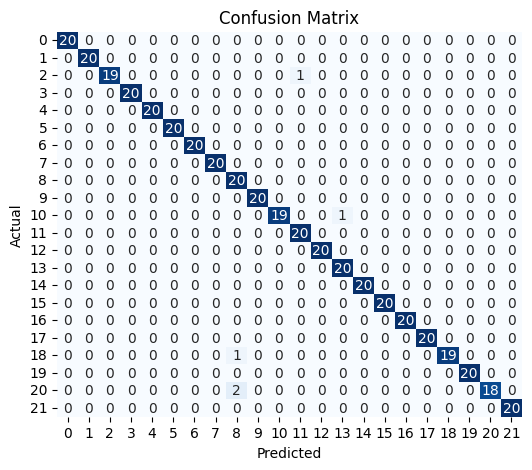

In [55]:
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) 
plt.title('Confusion Matrix') 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show() 

In [56]:
import pandas as pd
from sklearn.metrics import accuracy_score

results = []



for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)

NameError: name 'X_test' is not defined

In [ ]:
# def predict_crop(N, P, K, Soil_pH, Temperature, Humidity,
#                  Wind_Speed, Soil_Quality, Soil_Type):
#     """
#     Predict crop name from soil + weather parameters.
#     Soil_Type must be a string: "Loamy", "Peaty", "Sandy", "Clay", "Saline"
#     """

#     # 1. Make a one-row dataframe
#     sample = pd.DataFrame({
#         'Soil_Type':   [Soil_Type],   # text
#         'Soil_pH':     [Soil_pH],
#         'Temperature': [Temperature],
#         'Humidity':    [Humidity],
#         'Wind_Speed':  [Wind_Speed],
#         'N':           [N],
#         'P':           [P],
#         'K':           [K],
#         'Soil_Quality':[Soil_Quality]
#     })

#     # 2. Encode Soil_Type using the SAME soil_encoder
#     sample['Soil_Type'] = soil_encoder.transform(sample['Soil_Type'])

#     # 3. Scale numeric columns using the SAME scaler
#     sample_scaled = sample.copy()
#     sample_scaled[features] = scaler.transform(sample[features])

#     # 4. Predict encoded label
#     pred_encoded = best_model.predict(sample_scaled)[0]

#     # 5. Decode crop name using crop_encoder
#     pred_crop = crop_encoder.inverse_transform([pred_encoded])[0]

#     return pred_crop


In [ ]:
# print(
#     predict_crop(
#         N=60, P=40, K=30,
#         Soil_pH=6.5,
#         Temperature=25,
#         Humidity=100,
#         Wind_Speed=5,
#         Soil_Quality=30,
#         Soil_Type="Loamy"   # IMPORTANT: name, not number
#     )
# )


In [76]:
# import joblib

# # adjust names here if your variables are called differently
# joblib.dump(best_model,    "best_model.pkl")
# joblib.dump(scaler,        "scaler.pkl")
# joblib.dump(soil_encoder,  "soil_encoder.pkl")
# joblib.dump(crop_encoder,  "crop_encoder.pkl")

# print("All objects saved!")


In [77]:
# # app.py  --- Crop Recommendation App

# import streamlit as st
# import numpy as np
# import pandas as pd
# import joblib

# # =========================
# # 1. Load saved objects
# # =========================
# @st.cache_resource
# def load_artifacts():
#     best_model   = joblib.load("best_model.pkl")
#     scaler       = joblib.load("scaler.pkl")
#     soil_encoder = joblib.load("soil_encoder.pkl")
#     crop_encoder = joblib.load("crop_encoder.pkl")
#     return best_model, scaler, soil_encoder, crop_encoder

# best_model, scaler, soil_encoder, crop_encoder = load_artifacts()

# # numeric columns you scaled in notebook
# feachers = ['Soil_pH', 'Temperature', 'Humidity',
#             'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality']

# # =========================
# # 2. Helper: prediction
# # =========================
# def predict_crop_streamlit(
#         N, P, K,
#         Soil_pH, Temperature, Humidity, Wind_Speed,
#         Soil_Quality, Soil_Type_text):
    
#     # 1) Build one-row DataFrame (same column names as training)
#     sample = pd.DataFrame({
#         'Soil_Type':   [Soil_Type_text],   # string (Loamy, Peaty...)
#         'Soil_pH':     [Soil_pH],
#         'Temperature': [Temperature],
#         'Humidity':    [Humidity],
#         'Wind_Speed':  [Wind_Speed],
#         'N':           [N],
#         'P':           [P],
#         'K':           [K],
#         'Soil_Quality':[Soil_Quality]
#     })

#     # 2) Encode Soil_Type using the saved label encoder
#     soil_encoded = soil_encoder.transform(sample['Soil_Type'])
#     soil_encoded = soil_encoded.reshape(-1, 1)

#     # 3) Scale numeric features with the saved scaler
#     sample_num = sample[feachers]
#     sample_scaled = scaler.transform(sample_num)

#     # 4) Combine encoded soil type + scaled numeric features
#     X_final = np.concatenate([soil_encoded, sample_scaled], axis=1)

#     # 5) Predict encoded label & decode to crop name
#     pred_encoded = best_model.predict(X_final)[0]
#     pred_crop    = crop_encoder.inverse_transform([pred_encoded])[0]

#     return pred_crop

# # =========================
# # 3. Streamlit UI
# # =========================
# st.set_page_config(page_title="Crop Recommendation", layout="centered")

# st.title("🌾 Crop Recommendation System")
# st.write(
#     "Enter soil parameters and weather conditions, "
#     "and the model will suggest the **best crop**."
# )

# # Get soil type options from encoder
# soil_type_options = list(soil_encoder.classes_)

# col1, col2 = st.columns(2)

# with col1:
#     Soil_Type = st.selectbox("Soil Type", soil_type_options)
#     N = st.number_input("Nitrogen (N)", min_value=0.0, max_value=150.0, value=60.0, step=1.0)
#     P = st.number_input("Phosphorus (P)", min_value=0.0, max_value=150.0, value=40.0, step=1.0)
#     K = st.number_input("Potassium (K)", min_value=0.0, max_value=150.0, value=30.0, step=1.0)
#     Soil_pH = st.number_input("Soil pH", min_value=3.0, max_value=10.0, value=6.5, step=0.1)

# with col2:
#     Temperature = st.number_input("Temperature (°C)", min_value=-5.0, max_value=50.0, value=22.0, step=0.5)
#     Humidity    = st.number_input("Humidity (%)", min_value=0.0, max_value=100.0, value=80.0, step=1.0)
#     Wind_Speed  = st.number_input("Wind Speed (km/h)", min_value=0.0, max_value=50.0, value=5.0, step=0.5)
#     Soil_Quality = st.number_input("Soil Quality Index", min_value=0.0, max_value=100.0, value=30.0, step=1.0)

# if st.button("🔍 Predict Best Crop"):
#     crop = predict_crop_streamlit(
#         N=N, P=P, K=K,
#         Soil_pH=Soil_pH,
#         Temperature=Temperature,
#         Humidity=Humidity,
#         Wind_Speed=Wind_Speed,
#         Soil_Quality=Soil_Quality,
#         Soil_Type_text=Soil_Type
#     )

#     st.success(f"✅ Recommended Crop: **{crop}**")
